# 10 - Region Analysis & Customer Preference (CatBoost)

Notebook ini bertujuan untuk melakukan analisis wilayah (Region Analysis) menggunakan **CatBoost Classifier**. 
Fokus utamanya adalah membangun *Customer Preference Model* untuk memprediksi kategori produk (`Category`) apa yang paling mungkin dibeli oleh pelanggan berdasarkan demografi wilayah (`Region`, `City`), metode pembayaran (`Payment_mode`), dan metrik pesanan lainnya.

Keunggulan CatBoost di sini adalah kemampuannya untuk memproses data kategorikal secara *native* tanpa perlu melakukan *One-Hot Encoding* secara manual.

In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Import CatBoost dan Metrik Evaluasi
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Setup tema visualisasi
sns.set_theme(style='darkgrid', palette='viridis')

print("Library berhasil dimuat!")

Library berhasil dimuat!


## 1. Load Data & Preprocessing
Memuat dataset bersih yang sudah diproses di notebook `01_EDA_Cleaning.ipynb`. Kita akan menstandarisasi nama kolom agar konsisten.

In [3]:
# Load Dataset
current_dir = os.getcwd()
path_file = os.path.join(current_dir, "..", "Data", "Processed", "ecommerce_clean.csv")

try:
    df = pd.read_csv(path_file)
    # Standarisasi nama kolom (Kapital di huruf pertama)
    df.columns = [col.strip().capitalize() for col in df.columns]
    
    print(f"Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.")
    display(df.head(3))
except Exception as e:
    print(f"Gagal memuat data! Error: {e}")

Dataset berhasil dimuat dengan 5000 baris dan 17 kolom.


,Order_id,Order_date,Customer_name,Region,City,Category,Sub_category,Product_name,Quantity,Unit_price,Discount,Sales,Profit,Payment_mode,Month,Year,Is_trending
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,10,2024,0
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,8,2025,0
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,11,2023,1


## 2. Definisi Fitur & Split Data
Kita akan memilih fitur geografis dan transaksional sebagai variabel independen (`X`), dan kategori produk sebagai target (`y`). Kemudian, kita definisikan indeks fitur yang bersifat kategorikal agar CatBoost bisa memprosesnya secara otomatis.

In [4]:
# Pilih fitur yang akan digunakan
features = ['Region', 'City', 'Payment_mode', 'Discount', 'Quantity']
target = 'Category'

X = df[features].copy()
y = df[target].copy()

# Beri tahu CatBoost indeks kolom mana yang berupa teks/kategorikal
# Region (0), City (1), Payment_mode (2)
cat_features_indices = [0, 1, 2]

# Split data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribusi Kelas pada Data Latih (Target: Category):")
print(y_train.value_counts())

Distribusi Kelas pada Data Latih (Target: Category):
Category
Books          422
Furniture      422
Kitchen        422
Home Decor     412
Sports         409
Clothing       409
Toys           382
Electronics    378
Groceries      376
Beauty         368
Name: count, dtype: int64


## 3. Pelatihan Model CatBoost
Inisialisasi dan latih model `CatBoostClassifier`. Kita menggunakan `loss_function='MultiClass'` karena target (`Category`) memiliki lebih dari dua kelas/kategori.

In [5]:
# Inisialisasi model CatBoost
model_catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=50 # Menampilkan log setiap 50 iterasi
)

# Latih model
print("Memulai pelatihan CatBoost...")
model_catboost.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)
print("Pelatihan Model Selesai!")

Memulai pelatihan CatBoost...
0:	learn: 0.1242500	test: 0.1130000	best: 0.1130000 (0)	total: 241ms	remaining: 2m
50:	learn: 0.2447500	test: 0.1210000	best: 0.1270000 (12)	total: 4.39s	remaining: 38.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.127
bestIteration = 12

Shrink model to first 13 iterations.
Pelatihan Model Selesai!


## 4. Evaluasi Model
Melihat performa model dalam memprediksi preferensi kategori pelanggan menggunakan `classification_report`.

In [6]:
# Prediksi pada data uji
y_pred = model_catboost.predict(X_test)

# Tampilkan akurasi dan laporan klasifikasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {acc:.2f}\\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

Akurasi Model: 0.13\n
--- Classification Report ---
              precision    recall  f1-score   support

      Beauty       0.00      0.00      0.00        92
       Books       0.12      0.06      0.08       106
    Clothing       0.15      0.14      0.14       102
 Electronics       0.00      0.00      0.00        94
   Furniture       0.12      0.52      0.20       105
   Groceries       0.00      0.00      0.00        94
  Home Decor       0.15      0.16      0.15       103
     Kitchen       0.14      0.13      0.13       106
      Sports       0.11      0.21      0.14       102
        Toys       0.50      0.01      0.02        96

    accuracy                           0.13      1000
   macro avg       0.13      0.12      0.09      1000
weighted avg       0.13      0.13      0.09      1000



c:\Users\agung\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\agung\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\agung\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 5. Regional Feature Importance
Menganalisis fitur apa yang paling dominan dalam menentukan kategori produk yang dibeli oleh pelanggan. Apakah lokasi (Region/City) lebih berpengaruh daripada Diskon?

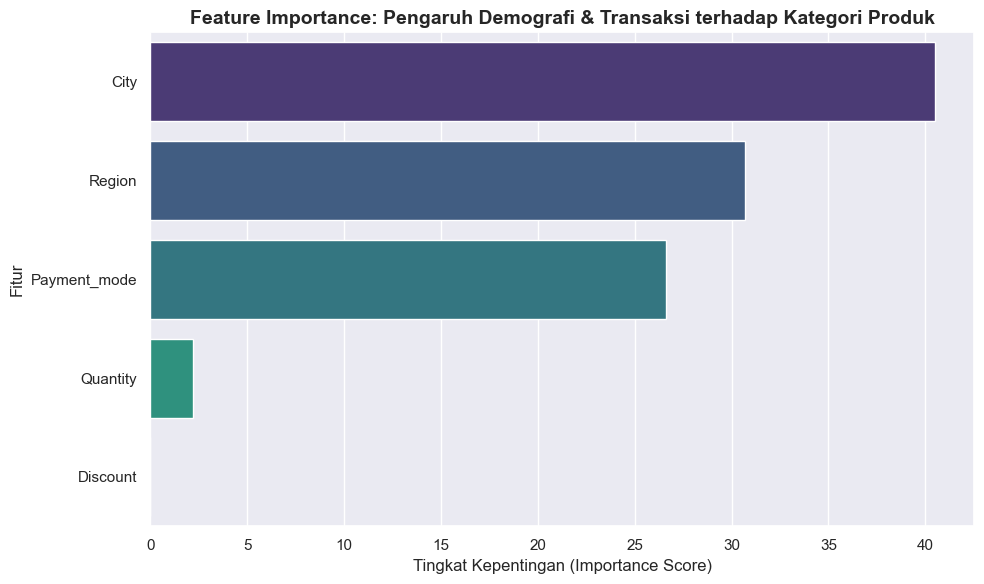

In [7]:
# Ambil tingkat kepentingan fitur dari model
feature_importances = model_catboost.get_feature_importance()

# Buat dataframe untuk visualisasi
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', dodge=False, legend=False)
plt.title('Feature Importance: Pengaruh Demografi & Transaksi terhadap Kategori Produk', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## 6. Simpan Model (Opsional untuk Deployment)
Menyimpan model yang sudah dilatih agar bisa diintegrasikan ke dalam dashboard Streamlit (`app.py`).

In [8]:
import joblib

# Buat direktori jika belum ada
os.makedirs("Model_Exports", exist_ok=True)

# Simpan model
model_path = os.path.join("Model_Exports", "model_catboost_region.pkl")
joblib.dump(model_catboost, model_path)

print(f"Model berhasil disimpan di: {model_path}")

Model berhasil disimpan di: Model_Exports\model_catboost_region.pkl
